# Correlation between ensemble differences between different experimental parameters

### Intialize IDPET

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from idpet.visualization import plot_comparison_matrix, Visualization
from idpet.ensemble import Ensemble
from idpet.ensemble_analysis import EnsembleAnalysis
from idpet.utils import set_verbosity

# Change verbosity level to show more information when performing the analysis.
set_verbosity("INFO")

from idpet.comparison import (
    score_adaJSD, get_adaJSD_matrix,
    score_ataJSD, get_ataJSD_profile,
    score_avg_jsd,
    score_ramaJSD, get_ramaJSD_profile,
    all_vs_all_comparison,
    process_all_vs_all_output
)

import os
import re
import subprocess


/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Intialize FAIRMD databank

In [2]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


In [3]:
import numpy as np

def compute_relaxation_differences(dict_a, dict_b):
    """
    Compute differences in T1, T2, and hetNOE between two nested dictionaries,
    and also calculate per-field RMSDs across residues.

    Parameters
    ----------
    dict_a, dict_b : dict
        Nested dictionaries of the form:
        {
            residue: {
                field: {
                    observable: {"value": float}
                }
            }
        }

    Returns
    -------
    results : dict
        {
            "differences": {
                residue: {
                    field: {
                        observable: diff (float or None)
                    }
                }
            },
            "rmsd": {
                field: {
                    observable: rmsd_value (float or None)
                }
            }
        }
        Differences are dict_a - dict_b.
    """
    differences = {}
    rmsd_data = {}  # collect differences for RMSD calculation

    residues = set(dict_a.keys()) | set(dict_b.keys())

    for res in residues:
        differences[res] = {}
        fields = set(dict_a.get(res, {}).keys()) | set(dict_b.get(res, {}).keys())
        for field in fields:
            differences[res][field] = {}
            for observable in ["T1", "T2", "hetNOE"]:
                val_a = dict_a.get(res, {}).get(field, {}).get(observable, {}).get("value")
                val_b = dict_b.get(res, {}).get(field, {}).get(observable, {}).get("value")
                if val_a is not None and val_b is not None:
                    diff = val_a - val_b
                    differences[res][field][observable] = diff
                    # store for RMSD
                    rmsd_data.setdefault(field, {}).setdefault(observable, []).append(diff)
                else:
                    differences[res][field][observable] = None

    # Compute RMSDs
    rmsd = {}
    for field, obs_dict in rmsd_data.items():
        rmsd[field] = {}
        for observable, diffs in obs_dict.items():
            diffs = np.array(diffs)
            rmsd[field][observable] = float(np.sqrt(np.mean(diffs**2))) if diffs.size > 0 else None

    return {"differences": differences, "rmsd": rmsd}


import numpy as np

def compute_relaxation_rate_differences(dict_a, dict_b):
    """
    Compute differences in R1=1/T1, R2=1/T2, and hetNOE between two nested dictionaries,
    and calculate per-field RMSDs across residues.

    Parameters
    ----------
    dict_a, dict_b : dict
        Nested dictionaries of the form:
        {
            residue: {
                field: {
                    observable: {"value": float}
                }
            }
        }

    Returns
    -------
    results : dict
        {
            "differences": {
                residue: {
                    field: {
                        R1: diff (float or None),
                        R2: diff (float or None),
                        hetNOE: diff (float or None)
                    }
                }
            },
            "rmsd": {
                field: {
                    R1: rmsd_value (float or None),
                    R2: rmsd_value (float or None),
                    hetNOE: rmsd_value (float or None)
                }
            }
        }
        Differences are dict_a - dict_b.
    """
    differences = {}
    rmsd_data = {}

    residues = set(dict_a.keys()) | set(dict_b.keys())

    for res in residues:
        differences[res] = {}
        fields = set(dict_a.get(res, {}).keys()) | set(dict_b.get(res, {}).keys())
        for field in fields:
            differences[res][field] = {}
            # R1 = 1/T1
            for obs, new_obs in [("T1", "R1"), ("T2", "R2")]:
                val_a = dict_a.get(res, {}).get(field, {}).get(obs, {}).get("value")
                val_b = dict_b.get(res, {}).get(field, {}).get(obs, {}).get("value")
                if val_a and val_b:  # avoid division by zero or None
                    r_a, r_b = 1.0 / val_a, 1.0 / val_b
                    diff = r_a - r_b
                    differences[res][field][new_obs] = diff
                    rmsd_data.setdefault(field, {}).setdefault(new_obs, []).append(diff)
                else:
                    differences[res][field][new_obs] = None

            # hetNOE (no inversion)
            val_a = dict_a.get(res, {}).get(field, {}).get("hetNOE", {}).get("value")
            val_b = dict_b.get(res, {}).get(field, {}).get("hetNOE", {}).get("value")
            if val_a is not None and val_b is not None:
                diff = val_a - val_b
                differences[res][field]["hetNOE"] = diff
                rmsd_data.setdefault(field, {}).setdefault("hetNOE", []).append(diff)
            else:
                differences[res][field]["hetNOE"] = None

    # Compute RMSDs
    rmsd = {}
    for field, obs_dict in rmsd_data.items():
        rmsd[field] = {}
        for observable, diffs in obs_dict.items():
            diffs = np.array(diffs)
            rmsd[field][observable] = float(np.sqrt(np.mean(diffs**2))) if diffs.size > 0 else None

    return {"differences": differences, "rmsd": rmsd}

import math
import numpy as np

def compute_chemical_shift_differences(dict1, dict2):
    """
    Compute chemical shift differences and RMSDs between two datasets.
    
    Parameters
    ----------
    dict1, dict2 : dict
        Dictionaries of the form:
        {
            residue_number: {
                nucleus: value,
                ...
            },
            ...
        }
    
    Returns
    -------
    results : dict
        {
            "differences": {
                residue_number: {
                    nucleus: difference (dict1 - dict2),
                    ...
                },
                ...
            },
            "rmsd": {
                nucleus: RMSD across all residues
            }
        }
    """
    differences = {}
    diff_by_nucleus = {}

    # Iterate over residues present in both
    for res in set(dict1.keys()).intersection(dict2.keys()):
        differences[res] = {}
        for nucleus in set(dict1[res].keys()).intersection(dict2[res].keys()):
            val1 = dict1[res][nucleus]
            val2 = dict2[res][nucleus]
            diff = val1 - val2
            differences[res][nucleus] = diff
            diff_by_nucleus.setdefault(nucleus, []).append(diff)

    # Compute RMSD per nucleus
    rmsd = {}
    for nucleus, diffs in diff_by_nucleus.items():
        if diffs:
            rmsd[nucleus] = math.sqrt(np.mean(np.square(diffs)))
        else:
            rmsd[nucleus] = None

    return {
        "differences": differences,
        "rmsd": rmsd
    }

def parse_trj_info(ID,systems):
    for system in systems:
        if system['ID'] != ID:
            continue
        data_folder = '../../Data/Simulations/' + system['path']
        trj_path = data_folder + system['TRJ'][0][0]
        """Extract replica name and force field from a trajectory file path."""
        fname = os.path.basename(trj_path)  # e.g. replica_03_AMBER03WS_md_1500ns.xtc
        parts = fname.split("_")
        replica = parts[0] + "_" + parts[1]   # "replica_03"
        forcefield = parts[2]                 # "AMBER03WS"
        return replica, forcefield

import os
import subprocess
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from functools import partial
import gc

def process_pair(IDs, systems):
    """
    Process and analyze a pair of molecular dynamics trajectories.

    This function locates trajectory files for two specified simulation systems,
    performs preprocessing with GROMACS (`trjconv`), loads the processed trajectories
    into `Ensemble` objects, and computes similarity scores and feature differences
    between the two ensembles.

    Parameters
    ----------
    IDs : list of str or int
        Identifiers of the two systems to analyze. Only systems with matching IDs
        from the `systems` input are processed.
    systems : list of dict
        A list of system descriptors, where each dictionary must contain:
          - 'ID' : str or int
              System identifier.
          - 'path' : str
              Relative path to the simulation data folder.
          - 'TRJ' : list
              Nested list with at least one entry, where the first item is the
              trajectory filename (XTC format).

    Returns
    -------
    dict
        Dictionary containing analysis metrics:
        - "ada_score" : float
            Jensen–Shannon divergence (ADA features).
        - "ata_score" : float
            Jensen–Shannon divergence (ATA features).
        - "rama_score" : float
            Jensen–Shannon divergence (Ramachandran features).
        - "rg_diff" : float
            Difference in mean radius of gyration between the two systems.

    Notes
    -----
    - This function assumes GROMACS is installed and accessible at
      `/usr/local/gromacs/bin/GMXRC`.
    - Processed trajectories (`nojump_traj.xtc`, `skipped_traj.xtc`) are written
      in the same folder as the original trajectory file.
    - Requires custom classes `Ensemble` and `EnsembleAnalysis` as well as
      scoring functions `score_adaJSD`, `score_ataJSD`, and `score_ramaJSD`.

    """
    ensembles = []

    file_paths = []   # now local, populated from systems
    for system in systems:
        ID = system['ID']
        if ID in IDs:
            data_folder = '../../Data/Simulations/' + system['path']
            trj = data_folder + system['TRJ'][0][0]
            gro = data_folder + 'protein_centered.gro'
            file_paths.append((ID, trj, gro))
    
    for ID, xtc_path, gro_path in file_paths:
        fname = os.path.splitext(os.path.basename(xtc_path))[0]
        code = ID
        folder_path = os.path.dirname(os.path.abspath(xtc_path))
    
        nojump_traj = folder_path + '/nojump_traj.xtc'
        skipped_traj = folder_path + '/skipped_traj.xtc'
        skip_value = 10

        if not os.path.exists(skipped_traj):
            cmd = f"""
            source /usr/local/gromacs/bin/GMXRC && \
            echo System | gmx trjconv -f {xtc_path} -s {gro_path} -skip {skip_value} -o {nojump_traj} -pbc nojump  && \
            echo -e "System\nSystem" | gmx trjconv -f {nojump_traj} -s {gro_path} -o {skipped_traj} -center
            """
            subprocess.run(cmd, shell=True, executable="/bin/bash", check=True)
    
        ens = Ensemble(code=code, data_path=skipped_traj, top_path=gro_path)
        ens.load_trajectory()
        ensembles.append(ens)

    analysis = EnsembleAnalysis(ensembles)
    analysis.load_trajectories()

    code_list = [e.code for e in analysis.ensembles]
    ens_1, ens_2 = analysis[code_list[0]], analysis[code_list[1]]

    print(f"Systems {code_list[0]} and {code_list[1]} analyzed")

    ens_1_rg = np.mean(ens_1.get_features("rg"))
    ens_2_rg = np.mean(ens_2.get_features("rg"))
    rg_diff = ens_1_rg - ens_2_rg
    
    ada_score, _ = score_adaJSD(ens_1, ens_2, bins="auto", return_bins=True)
    ata_score, _ = score_ataJSD(ens_1, ens_2, bins="auto", return_bins=True)
    rama_score, _ = score_ramaJSD(ens_1, ens_2, bins=5, return_bins=True)

    # cleanup
    del ens_1, ens_2, analysis
    gc.collect()

    return {
        "ada_score": ada_score,
        "ata_score": ata_score,
        "rama_score": rama_score,
        "rg_diff": rg_diff,
    }

def make_rmsd_scores(rmsd_data):
    # Step 1: find minimum RMSD per class
    min_rmsd_per_class = {}
    for sim, values in rmsd_data.items():
        for cls, rmsd in values.items():
            if rmsd is None:
                continue
            if cls not in min_rmsd_per_class or rmsd < min_rmsd_per_class[cls]:
                min_rmsd_per_class[cls] = rmsd

    # Step 2+3: compute CSScore for each simulation
    cs_scores = {}
    for sim, values in rmsd_data.items():
        normed = []
        for cls, rmsd in values.items():
            if rmsd is None or cls not in min_rmsd_per_class:
                continue
            normed.append(rmsd / min_rmsd_per_class[cls])
        cs_scores[sim] = np.mean(normed) if normed else None

    return cs_scores

# Results
#print("Minimum RMSD per class:", min_rmsd_per_class)
#print("CS Scores per simulation:")
#for sim, score in cs_scores.items():
#    print(f"  {sim}: {score:.3f}")

def calculate_backbone_correlation_distributions(gro_file, xtc_file, output_file, bins=50):

    outfile_png = output_file
    outfile_csv = output_file.replace(".png", ".csv")
    outfile_dist = output_file.replace(".png", "_dist.csv")

    u = mda.Universe(gro_file, xtc_file)
    CAatoms = u.select_atoms("name CA")

    num_atoms = len(CAatoms)
    num_vectors = num_atoms - 1
    vec = np.zeros((num_vectors, 3))
    avg_matrix = np.zeros((num_vectors, num_vectors))

    # Histogram setup
    bin_edges = np.linspace(-1, 1, bins + 1)
    histograms = np.zeros((num_vectors, num_vectors, bins), dtype=int)

    for ts in u.trajectory:
        # Build backbone vectors
        for i in range(num_vectors):
            vec[i] = CAatoms[i + 1].position - CAatoms[i].position
            vec[i] /= np.linalg.norm(vec[i])
        corr_matrix = np.dot(vec, vec.T)

        avg_matrix += corr_matrix

        # Update histograms
        for i in range(num_vectors):
            for j in range(num_vectors):
                val = corr_matrix[i, j]
                bin_idx = np.searchsorted(bin_edges, val, side="right") - 1
                if 0 <= bin_idx < bins:
                    histograms[i, j, bin_idx] += 1

    # Normalize average matrix
    avg_matrix /= len(u.trajectory)

    # Save average matrix
    np.savetxt(outfile_csv, avg_matrix, delimiter=",")

    # Save histograms (flattened table for easier use later)
    col_names = [f"pair_{i}_{j}" for i in range(num_vectors) for j in range(num_vectors)]
    df_hist = pd.DataFrame(
        histograms.reshape(num_vectors * num_vectors, bins).T,
        columns=col_names
    )
    df_hist["bin_left"] = bin_edges[:-1]
    df_hist["bin_right"] = bin_edges[1:]
    df_hist.to_csv(outfile_dist, index=False)

from scipy.spatial.distance import jensenshannon

def calculate_js_matrix_IDs(ID1, ID2, systems, output_csv, output_png=None):
    """
    Calculate the Jensen-Shannon divergence matrix between distributions
    stored in two *_dist.csv files (created by calculate_backbone_correlation_distributions).

    Parameters
    ----------
    dist_file1 : str
        Path to first *_dist.csv file
    dist_file2 : str
        Path to second *_dist.csv file
    output_csv : str
        Path to save JS divergence matrix as CSV
    output_png : str, optional
        Path to save heatmap as PNG (if given)

    Returns
    -------
    js_matrix : np.ndarray
        Square matrix of JS divergence values
    js_mean : float
        Average JS divergence across all pairs
    """

    for system in systems:
        ID = system['ID']
        if ID == ID1:
            data_folder = '../../Data/Simulations/' + system['path']
            dist_file1 = data_folder + 'backbone_correlation_distribution.csv'
        if ID == ID2:
            data_folder = '../../Data/Simulations/' + system['path']
            dist_file2 = data_folder + 'backbone_correlation_distribution.csv'
        else:
            continue
    
    # Load both distribution files
    df1 = pd.read_csv(dist_file1)
    df2 = pd.read_csv(dist_file2)

    # Ensure same bins
    if not np.allclose(df1["bin_left"], df2["bin_left"]):
        raise ValueError("Bin edges in the two files do not match.")
    
    # Drop bin edges
    df1 = df1.drop(columns=["bin_left", "bin_right"])
    df2 = df2.drop(columns=["bin_left", "bin_right"])

    # Ensure same columns
    if list(df1.columns) != list(df2.columns):
        raise ValueError("Pair columns do not match between files.")
    
    col_names = df1.columns
    num_pairs = len(col_names)
    n_vectors = int(np.sqrt(num_pairs))

    # Calculate JS divergence per pair
    js_values = []
    for col in col_names:
        p = df1[col].values.astype(float)
        q = df2[col].values.astype(float)

        # Normalize to probability distributions
        p = p / p.sum() if p.sum() > 0 else np.zeros_like(p)
        q = q / q.sum() if q.sum() > 0 else np.zeros_like(q)

        # JS divergence
        js = jensenshannon(p, q, base=2) ** 2  # scipy returns sqrt(JS), so square it
        js_values.append(js)

    # Reshape into square matrix
    js_matrix = np.array(js_values).reshape(n_vectors, n_vectors)

    # Compute average divergence
    js_mean = np.nanmean(js_matrix)

    # Save CSV
    np.savetxt(output_csv, js_matrix, delimiter=",")

    # Optional: plot heatmap
    if output_png is not None:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6,5))
        im = plt.imshow(js_matrix, cmap="viridis", origin="lower")
        cbar = plt.colorbar(im)
        cbar.ax.tick_params(labelsize=12)
        plt.xlabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.ylabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.title("Jensen-Shannon Divergence Matrix", fontsize=14)
        plt.tight_layout()
        plt.savefig(output_png, dpi=600)
        plt.close()

    return js_matrix, js_mean

from scipy.spatial.distance import jensenshannon
def calculate_js_matrix(dist_file1, dist_file2, output_csv, output_png=None):
    """
    Calculate the Jensen-Shannon divergence matrix between distributions
    stored in two *_dist.csv files (created by calculate_backbone_correlation_distributions).

    Parameters
    ----------
    dist_file1 : str
        Path to first *_dist.csv file
    dist_file2 : str
        Path to second *_dist.csv file
    output_csv : str
        Path to save JS divergence matrix as CSV
    output_png : str, optional
        Path to save heatmap as PNG (if given)

    Returns
    -------
    js_matrix : np.ndarray
        Square matrix of JS divergence values
    js_mean : float
        Average JS divergence across all pairs
    """
    # Load both distribution files
    df1 = pd.read_csv(dist_file1)
    df2 = pd.read_csv(dist_file2)

    # Ensure same bins
    if not np.allclose(df1["bin_left"], df2["bin_left"]):
        raise ValueError("Bin edges in the two files do not match.")
    
    # Drop bin edges
    df1 = df1.drop(columns=["bin_left", "bin_right"])
    df2 = df2.drop(columns=["bin_left", "bin_right"])

    # Ensure same columns
    if list(df1.columns) != list(df2.columns):
        raise ValueError("Pair columns do not match between files.")
    
    col_names = df1.columns
    num_pairs = len(col_names)
    n_vectors = int(np.sqrt(num_pairs))

    # Calculate JS divergence per pair
    js_values = []
    for col in col_names:
        p = df1[col].values.astype(float)
        q = df2[col].values.astype(float)

        # Normalize to probability distributions
        p = p / p.sum() if p.sum() > 0 else np.zeros_like(p)
        q = q / q.sum() if q.sum() > 0 else np.zeros_like(q)

        # JS divergence
        js = jensenshannon(p, q, base=2) ** 2  # scipy returns sqrt(JS), so square it
        js_values.append(js)

    # Reshape into square matrix
    js_matrix = np.array(js_values).reshape(n_vectors, n_vectors)

    # Compute average divergence
    js_mean = np.nanmean(js_matrix)

    # Save CSV
    np.savetxt(output_csv, js_matrix, delimiter=",")

    # Optional: plot heatmap
    if output_png is not None:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6,5))
        im = plt.imshow(js_matrix, cmap="viridis", origin="lower")
        cbar = plt.colorbar(im)
        cbar.ax.tick_params(labelsize=12)
        plt.xlabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.ylabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.title("Jensen-Shannon Divergence Matrix", fontsize=14)
        plt.tight_layout()
        plt.savefig(output_png, dpi=600)
        plt.close()

    return js_matrix, js_mean

import json
import pandas as pd

def load_and_flatten(input_file, output_csv=None):
    """
    Load list of dicts from a JSON file and flatten into a pandas DataFrame.

    Parameters
    ----------
    input_file : str
        Path to JSON file containing the list of dicts
    output_csv : str, optional
        If given, save the resulting DataFrame to CSV

    Returns
    -------
    df : pandas.DataFrame
        Flattened DataFrame
    """
    # Load JSON data
    with open(input_file, "r") as f:
        data = json.load(f)

    # Flatten entries
    flat_rows = []
    for d in data:
        row = {
            "ID": d["ID"],
            "Replica": d["simulation"][0],
            "Forcefield": d["simulation"][1],
            "Rank": d["Rank"],
            "backbone_comparison": d["backbone_comparison"],
        }

        # Expand ensemble_comparison if it's a dict
        if isinstance(d["ensemble_comparison"], dict):
            row.update(d["ensemble_comparison"])
        else:
            row["ada_score"] = None
            row["ata_score"] = None
            row["rama_score"] = None
            row["rg_diff"] = None

        flat_rows.append(row)

    # Build DataFrame
    df = pd.DataFrame(flat_rows)

    # Sort by Rank
    df = df.sort_values("Rank").reset_index(drop=True)

    # Optional save
    if output_csv:
        df.to_csv(output_csv, index=False)

    return df


# Example usage
#if __name__ == "__main__":
#    df = load_and_flatten("input.json", "summary_table.csv")
#    print(df.to_string(index=False))


### Create pairs of FAIRDMD databank IDs for a set of simulations of a given protein

In [4]:
import itertools

#protein = 'ChiZ1-64'
#protein = 'KRS1-72'
#protein = 'asyn'
protein = 'icl2'

all_IDs = []
for system in systems:
    if protein in system['SYSTEM']:
        all_IDs.append(system['ID'])

print('Found IDs: ', all_IDs)

pairs = list(itertools.combinations(all_IDs, 2))

Found IDs:  [54, 55, 56, 58, 59, 60, 64, 67, 68, 70, 72, 75, 78, 79, 80, 82, 83, 84, 85, 94, 95, 96, 97]


In [5]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_system(system):
    ID = system['ID']
    output_file = f"../../Data/Simulations/{system['path']}backbone_correlation_distribution.csv"

    if os.path.isfile(output_file):
        return f"Skipping {ID}: output already exists."

    print(f"Calculating for {ID} at ../../Data/Simulations/{system['path']}")
    xtc_file = f"../../Data/Simulations/{system['path']}{system['TRJ'][0][0]}"
    gro_file = f"../../Data/Simulations/{system['path']}protein_centered.gro"

    calculate_backbone_correlation_distributions(gro_file, xtc_file, output_file)
    return f"Finished {ID}"

# ---- Main parallel loop ----
with ProcessPoolExecutor(max_workers=20) as executor:
    futures = [executor.submit(process_system, system) for system in systems if system['ID'] in all_IDs]

    for future in as_completed(futures):
        try:
            print(future.result())
        except Exception as e:
            print(f"Error: {e}")


Calculating for 56 at ../../Data/Simulations/b54/385/b543854bc243b67fe9728b1e9fb7b9f74e545a57/1080ba49b42a695e49d9b33d3bb1e2c5b2826e5c/Calculating for 54 at ../../Data/Simulations/c38/bdc/c38bdc2422ae3ef952ed96dd1fd1ad1a7026e818/86e2e453be37143782c0d004d3c892f549cac468/Calculating for 70 at ../../Data/Simulations/792/e4e/792e4e4d39a0f684cdd916d0b254e8132da687ec/a4612ad8e94cff42953836487b81d113547fb5f0/Calculating for 58 at ../../Data/Simulations/94f/92f/94f92f2735ca68e8f7fc30e6ff81100c6a2e9616/7c660e02709e0e2970ab829fa2663aa2b96ebb35/Calculating for 75 at ../../Data/Simulations/33a/4b6/33a4b6d768ec17f76def70631c65412fc4edf232/ce4ce727d21d2041a5ab560528cf0aa84569cdb9/Calculating for 55 at ../../Data/Simulations/1d7/df7/1d7df70c95b87e6fa6e9eaec89d9048447e313df/f6abb3ba1d3f0f2b49b6425d4091e16877e2dfe8/Calculating for 59 at ../../Data/Simulations/e60/c94/e60c94e72ecac859751e469d431b90d66d1ab68d/7aac44b93c91816d3baca1ffc5f604a660b4574b/Calculating for 78 at ../../Data/Simulations/8c3/048/8c

In [5]:
for system in systems:
    ID = system['ID']
    if ID in all_IDs:
        output_file = '../../Data/Simulations/' + system['path'] + 'backbone_correlation_distribution.csv'
        if os.path.isfile(output_file):
            continue
        print('Calculating for ', ID, 'at ../../Data/Simulations/' + system['path'])
        xtc_file = '../../Data/Simulations/' + system['path'] +  system['TRJ'][0][0]
        gro_file = '../../Data/Simulations/' + system['path'] +  'protein_centered.gro'
        calculate_backbone_correlation_distributions(gro_file, xtc_file, output_file)

Calculating for  52 at ../../Data/Simulations/c5c/94a/c5c94a1f5c1aa87393804181dd4630b40eae58f9/babd9acb94742a58359e7ca0c7541ee9c6fdafb8/


KeyboardInterrupt: 

In [5]:
rmsd_data = {}
sr_rmsd_data = {}

for system in systems:
    ID = system['ID']
    if ID in all_IDs:
        data_folder = '../../Data/Simulations/' + system['path']
        spin_relaxation_file_rmsd = data_folder + 'spin_relaxation_rmsd.yaml'
        chemical_shift_file_rmsd = data_folder + 'chemical_shift_rmsd.yaml'
        with open(spin_relaxation_file_rmsd, "r") as f:
            spin_relaxation_rmsd = yaml.safe_load(f)
        with open(chemical_shift_file_rmsd, "r") as f:
            chemical_shift_rmsd = yaml.safe_load(f)
        # Step 1: extract the top-level RMSD block (non-integer keys)
        rmsd_block = {k: v for k, v in chemical_shift_rmsd.items() if k != "differences" and not isinstance(k, int)}
        # Step 2: wrap into the rmsd_data format
        rmsd_data[ID] = rmsd_block
        # Step 1: extract the top-level RMSD block (non-integer keys)
        sr_rmsd_block = {k: v for k, v in spin_relaxation_rmsd.items() if k != "differences" and not isinstance(k, int)}
        # Step 2: wrap into the rmsd_data format
        sr_rmsd_data[ID] = sr_rmsd_block

FileNotFoundError: [Errno 2] No such file or directory: '../../Data/Simulations/c38/bdc/c38bdc2422ae3ef952ed96dd1fd1ad1a7026e818/86e2e453be37143782c0d004d3c892f549cac468/chemical_shift_rmsd.yaml'

In [8]:
cs_scores = make_rmsd_scores(rmsd_data)
sr_scores = make_rmsd_scores(sr_rmsd_data)

Loading trajectory for 14...



Ranking in List 2 spin relaxation times (ID -> Value -> Rank):
ID (25, 'replica_02', 'AMBER99SBWS'): Value 1.2266, Rank 1, 0, 'Backbone comparison', 0


Loading trajectory for 25...
Loading trajectory for 14...
Loading trajectory for 25...


Systems 14 and 25 analyzed


Loading trajectory for 25...


...

Systems 1 and 46 analyzed


Loading trajectory for 46...


ID (1, 'replica_02', 'DESAMBER'): Value 1.3733, Rank 23, {'ada_score': 0.15813961199005705, 'ata_score': 0.1554619274078301, 'rama_score': 0.14578845148259612, 'rg_diff': 0.11233833546414274}, 'Backbone comparison', 0.04156687115851396


Loading trajectory for 48...
Loading trajectory for 46...
Loading trajectory for 48...


Systems 46 and 48 analyzed
ID (48, 'replica_05', 'AMBER99SB-DISP'): Value 1.3932, Rank 24, {'ada_score': 0.1673476079572334, 'ata_score': 0.17137999007678048, 'rama_score': 0.14222860365514997, 'rg_diff': 0.07159175152784947}, 'Backbone comparison', 0.04855676846393942

Spearman rank correlation: 0.39652173913043476
Kendall's tau correlation: 0.33333333333333337


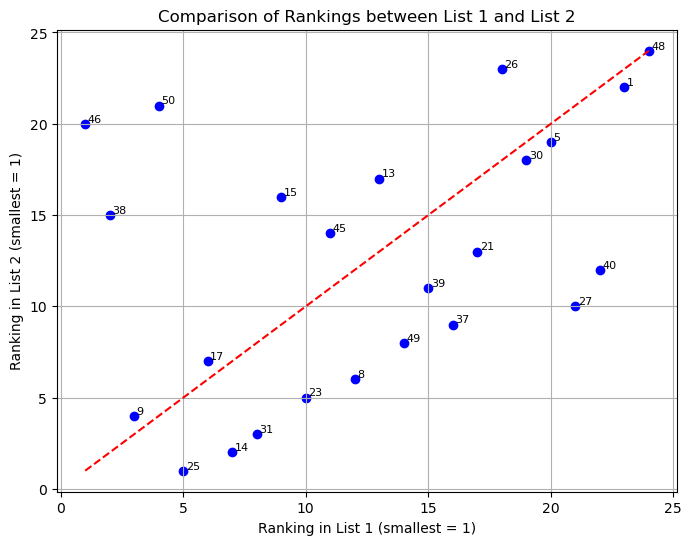

In [9]:
from scipy.stats import spearmanr, kendalltau, rankdata
import matplotlib.pyplot as plt

dict1 = cs_scores
dict2 = sr_scores

# Common IDs
common_ids = list(dict1.keys() & dict2.keys())

# Extract values in matching order
vals1 = [dict1[i] for i in common_ids]
vals2 = [dict2[i] for i in common_ids]

# Compute rank orders (ascending, so smallest value = rank 1)
ranks1 = rankdata(vals1, method="ordinal")
ranks2 = rankdata(vals2, method="ordinal")

print("\nRanking in List 2 spin relaxation times (ID -> Value -> Rank):")
first_sr = None
sr_ranking = []
for i, v, r in sorted(zip(common_ids, vals2, ranks2), key=lambda x: x[2]):
    if first_sr is None:
        first_sr = i
        ensemble_comparison = 0
        backbone_comparison = 0
    else:
        IDs = [first_sr,i]
        #print(i)
        ensemble_comparison = process_pair(IDs, systems)
        output_csv = "js_matrix_sr" + str(r) + ".csv"
        output_png = "js_matrix_sr" + str(r) + ".png"
        js_matrix, backbone_comparison = calculate_js_matrix_IDs(first_sr, i, systems, output_csv, output_png)

    #print(ensemble_comparison)
    replica, ff = parse_trj_info(i,systems)
    print(f"ID {i,replica,ff}: Value {v:.4f}, Rank {r}, {ensemble_comparison}, 'Backbone comparison', {backbone_comparison}")
    sr_ranking.append(
        {'ID':i, 
         'value': v,
         'simulation': (replica,ff), 
         'Rank': r, 
         'ensemble_comparison': ensemble_comparison,
         'backbone_comparison': backbone_comparison
        }
    )


# Print rank orders with values
print("Ranking in List 1 chemical shifts (ID -> Value -> Rank):")
first_cs = None
cs_ranking = []
for i, v, r in sorted(zip(common_ids, vals1, ranks1), key=lambda x: x[2]):
    if first_cs is None:
        first_cs = i
        ensemble_comparison = 0
        backbone_comparison = 0
    else:
        IDs = [first_cs,i]
        #print(i)
        ensemble_comparison = process_pair(IDs, systems)
        output_csv = "js_matrix_cs" + str(r) + ".csv"
        output_png = "js_matrix_cs" + str(r) + ".png"
        js_matrix, backbone_comparison = calculate_js_matrix_IDs(first_cs, i, systems, output_csv, output_png)
    
    #print(ensemble_comparison)
    replica, ff = parse_trj_info(i,systems)
    print(f"ID {i,replica,ff}: Value {v:.4f}, Rank {r}, {ensemble_comparison}, 'Backbone comparison', {backbone_comparison}")
    cs_ranking.append(
        {'ID':i, 
         'value': v,
         'simulation': (replica,ff), 
         'Rank': r, 
         'ensemble_comparison': ensemble_comparison,
         'backbone_comparison': backbone_comparison
        }
    )



# Compute correlations
spearman_corr, _ = spearmanr(vals1, vals2)
kendall_corr, _ = kendalltau(vals1, vals2)

print("\nSpearman rank correlation:", spearman_corr)
print("Kendall's tau correlation:", kendall_corr)

# Plot rankings
plt.figure(figsize=(8,6))
plt.scatter(ranks1, ranks2, color="blue")

# Add diagonal reference line
plt.plot([1, len(common_ids)], [1, len(common_ids)], "r--")

# Label points with ID
for i, (x, y) in enumerate(zip(ranks1, ranks2)):
    plt.text(x+0.1, y+0.1, str(common_ids[i]), fontsize=8)

plt.xlabel("Ranking in List 1 (smallest = 1)")
plt.ylabel("Ranking in List 2 (smallest = 1)")
plt.title("Comparison of Rankings between List 1 and List 2")
plt.grid(True)
plt.show()

In [11]:
# Save to file
sr_ranking_file = "sr_ranking" + protein +".json"
with open(sr_ranking_file, "w") as f:
    json.dump(sr_ranking, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.integer, np.floating)) else str(x))

cs_ranking_file = "cs_ranking" + protein +".json"
with open(cs_ranking_file, "w") as f:
    json.dump(cs_ranking, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.integer, np.floating)) else str(x))



In [12]:
load_and_flatten(sr_ranking_file, output_csv=None)

,ID,Replica,Forcefield,Rank,backbone_comparison,ada_score,ata_score,rama_score,rg_diff
0,25,replica_02,AMBER99SBWS,1.0,0.000000,NaN,NaN,NaN,NaN
1,14,replica_04,AMBER03WS,2.0,0.011911,0.061532,0.095015,0.108777,0.302854
2,31,replica_03,AMBER03WS,3.0,0.010944,0.054678,0.092321,0.110710,-0.196205
3,9,replica_01,CHARMM36M,4.0,0.037272,0.167811,0.158237,0.177397,-0.197956
4,23,replica_02,AMBER03WS,5.0,0.012546,0.051629,0.102176,0.117753,0.157139
5,8,replica_05,CHARMM36M,6.0,0.042031,0.175174,0.175552,0.171844,-0.248015
6,17,replica_02,CHARMM36M,7.0,0.042133,0.155653,0.151025,0.160118,-0.324768
7,49,replica_01,AMBER99SBWS,8.0,0.012506,0.033016,0.061909,0.063933,0.063417
8,37,replica_05,AMBER03WS,9.0,0.017913,0.086332,0.120873,0.136409,-0.136181
9,27,replica_05,AMBER99SBWS,10.0,0.022913,0.078918,0.100690,0.102996,0.191417


In [13]:
load_and_flatten(cs_ranking_file, output_csv=None)

,ID,Replica,Forcefield,Rank,backbone_comparison,ada_score,ata_score,rama_score,rg_diff
0,46,replica_01,AMBER99SB-DISP,1.0,0.000000,NaN,NaN,NaN,NaN
1,38,replica_02,AMBER99SB-DISP,2.0,0.023743,0.078717,0.094744,0.076001,0.181266
2,9,replica_01,CHARMM36M,3.0,0.042962,0.163738,0.142577,0.140572,-0.300314
3,50,replica_03,AMBER99SB-DISP,4.0,0.031255,0.100266,0.115748,0.104510,0.066856
4,25,replica_02,AMBER99SBWS,5.0,0.024834,0.073006,0.137566,0.142138,-0.102359
5,17,replica_02,CHARMM36M,6.0,0.050396,0.165384,0.146715,0.132369,-0.427127
6,14,replica_04,AMBER03WS,7.0,0.023328,0.075668,0.119584,0.119804,0.200496
7,31,replica_03,AMBER03WS,8.0,0.022654,0.074692,0.117763,0.121858,0.093847
8,15,replica_05,DESAMBER,9.0,0.031685,0.111654,0.135152,0.128713,-0.049830
9,23,replica_02,AMBER03WS,10.0,0.025289,0.078907,0.131527,0.132123,0.054781


In [26]:
data = sr_ranking
import pandas as pd

# Flatten entries
flat_rows = []
for d in data:
    row = {
        "ID": d["ID"],
        "Replica": d["simulation"][0],
        "Forcefield": d["simulation"][1],
        "Rank": d["Rank"],
        "Value": d["value"],
        "backbone_comparison": d["backbone_comparison"],
    }

    # Expand ensemble_comparison if it's a dict
    if isinstance(d["ensemble_comparison"], dict):
        row.update(d["ensemble_comparison"])
    else:
        row["ada_score"] = None
        row["ata_score"] = None
        row["rama_score"] = None
        row["rg_diff"] = None

    flat_rows.append(row)

# Make DataFrame
df = pd.DataFrame(flat_rows)

# Sort by Rank (optional)
df = df.sort_values("Rank")

# Pretty print
print(df.to_string(index=False))

# Save nicely if you want
df.to_csv("summary_table.csv", index=False)


 ID    Replica     Forcefield  Rank    Value  backbone_comparison  ada_score  ata_score  rama_score   rg_diff
 41 replica_04 AMBER99SB-DISP     1 1.320864             0.000000        NaN        NaN         NaN       NaN
 24 replica_01 AMBER99SB-DISP     2 1.356818             0.008548   0.072350   0.073066    0.041121  0.094428
 22 replica_05 AMBER99SB-DISP     3 1.370612             0.011823   0.088600   0.073018    0.044101  0.102528
 43 replica_02       DESAMBER     4 1.380707             0.032638   0.127577   0.134438    0.099024  0.387424
 12 replica_05      CHARMM36M     5 1.396430             0.072507   0.250961   0.185576    0.127174 -0.779634
 28 replica_01      CHARMM36M     6 1.398777             0.043672   0.233931   0.147362    0.122909 -0.921412
  7 replica_03      CHARMM36M     7 1.427920             0.042635   0.235422   0.119901    0.099898 -0.868865
 33 replica_04       DESAMBER     8 1.559637             0.013593   0.050335   0.072009    0.069033 -0.122194
 16 replic